## Support Vector Regressor

Support Vector Machine (SVM) is a very popular Machine Learning algorithm that is used in both Regression and Classification. Support Vector Regression is similar to Linear Regression in that the equation of the line is y= wx+b In SVR, this straight line is referred to as hyperplane. The data points on either side of the hyperplane that are closest to the hyperplane are called Support Vectors which is used to plot the boundary line.

Unlike other Regression models that try to minimize the error between the real and predicted value, the SVR tries to fit the best line within a threshold value (Distance between hyperplane and boundary line), a. Thus, we can say that SVR model tries satisfy the condition -a < y-wx+b < a. It used the points with this boundary to predict the value.

For a non-linear regression, the kernel function transforms the data to a higher dimensional and performs the linear separation. Here we will use the rbf kernel.

In this example, we will go through the implementation of Support Vector Regression (SVM), in which we will predict the Marks of a student based on his or her number of hours put into study.

### Problem Analysis

In this data, we have one independent variable Hours of Study and one dependent variable Marks. In this problem, we have to train a SVR model with this data to understand the correlation between the Hours of Study and Marks of the student and be able to predict the student’s mark based on their number of hours dedicated to studies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [40]:
dataset = pd.read_csv('Student_Marks.csv')
dataset.head()

,time_study,Marks
0,4.508,19.202
1,0.096,7.734
2,3.133,13.811
3,7.909,53.018
4,7.811,55.299


In [41]:
X = dataset.iloc[:, 0].values
y = dataset.iloc[:, 1].values
y = np.array(y).reshape(-1,1)

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [43]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train.reshape(-1,1), y_train.reshape(-1,1))

C:\Users\gn221m\Anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [45]:
y_pred = regressor.predict(X_test.reshape(-1,1))

In [46]:
y_pred

array([11.34305497, 12.81418738, 12.94652381, 31.86716462, 12.74163849,
       38.26371563, 15.65611024, 16.24353395, 17.9624764 , 17.90621271,
       17.24894575, 16.52085769, 32.91808393, 12.35073863, 20.45478159,
       21.19820015, 34.65529181, 23.81655785, 38.1814411 , 34.08651654])

In [47]:
df = pd.DataFrame({'Real Values':y_test.reshape(-1), 'Predicted Values':y_pred.reshape(-1)})
df

,Real Values,Predicted Values
0,6.053,11.343055
1,7.336,12.814187
2,7.734,12.946524
3,36.653,31.867165
4,12.209,12.741638
5,55.299,38.263716
6,13.119,15.656110
7,13.811,16.243534
8,19.590,17.962476
9,19.771,17.906213


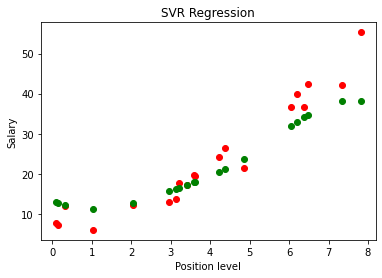

In [49]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X_test,y_test.reshape(-1), color = 'red')
plt.scatter(X_test, y_pred, color = 'green')
plt.title('SVR Regression')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

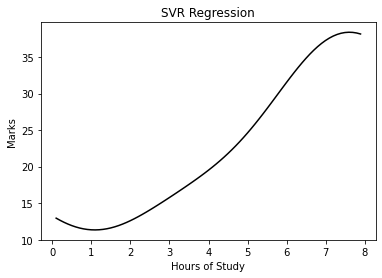

In [50]:
plt.plot(X_grid, regressor.predict(X_grid), color = 'black')
plt.title('SVR Regression')
plt.xlabel('Hours of Study')
plt.ylabel('Marks')
plt.show()